In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import geopandas as gpd
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("data/data.csv")

In [70]:
def plot_tsne(tsne_results, highlight_indices, highlight_colors, highlight_names):
    """Plots the 2D t-SNE projection highlighting specific data points."""
    plt.figure(figsize=(10, 8))
    
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], color='lightgray', alpha=0.5, label='Other Countries')
    for idx, color, name in zip(highlight_indices, highlight_colors, highlight_names):
        plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                    color=color, s=150, edgecolors='black', label=name, zorder=5)
        
    plt.title('t-SNE Projection (No Preprocessing)', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig('images/tsne_plot.png', bbox_inches='tight')
    plt.show()

def plot_world_map(df, country_col, highlight_indices, highlight_colors, highlight_names):
    """Plots highlighted countries onto a Geopandas world map with consistent colors."""
    
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(world_url)
    except Exception:
        fallback_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
        world = gpd.read_file(fallback_url)
        
    world['color'] = 'lightgray' 
    
    highlight_dict = dict(zip(highlight_names, highlight_colors))
    
    name_col = 'NAME' if 'NAME' in world.columns else 'name'    
    for idx, name in zip(highlight_indices, highlight_names):
        country_name = df.loc[idx, country_col]
        if country_name == "United States":
            country_name = "United States of America"
            
        world.loc[world[name_col].str.contains(country_name, case=False, na=False), 'color'] = highlight_dict[name]
        
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    world.plot(ax=ax, color=world['color'], edgecolor='black', linewidth=0.5)
    
    # Create matching legend patches
    import matplotlib.patches as mpatches
    patches = [mpatches.Patch(color=c, label=n) for n, c in highlight_dict.items()]
    plt.legend(handles=patches, loc='lower left', title="Highlighted Countries")
    
    plt.title('World Map: Highlighting Key Countries', fontsize=16)
    plt.axis('off')
    plt.savefig('images/1_world_map.png', bbox_inches='tight')
    plt.show()
    
def ignorant_analysis(df, country_col='country'):
    """Main function executing TSNE and calling the two plotting functions."""
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Perform t-SNE
    tsne = TSNE(n_components=2, perplexity=10, max_iter=2500, random_state=42)
    tsne_results = tsne.fit_transform(numeric_df)
    
    # Identify specific interesting points
    idx_max_gdp = df['gdpp'].idxmax()
    idx_min_gdp = df['gdpp'].idxmin()
    idx_max_mort = df['child_mort'].idxmax()
    idx_max_life_exp = df['life_expec'].idxmax()
    idx_max_total_fer = df['total_fer'].idxmax()
    idx_min_total_fer = df['total_fer'].idxmin()
    
    highlight_indices = [idx_max_gdp, idx_min_gdp, idx_max_mort, idx_max_life_exp, idx_max_total_fer, idx_min_total_fer]
    highlight_colors = ['tab:green', 'tab:red', 'tab:orange', 'tab:blue', 'tab:olive', 'tab:cyan']

    # tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan
    highlight_names = [f"Max GDP: {df.loc[idx_max_gdp, country_col]}", 
                       f"Min GDP: {df.loc[idx_min_gdp, country_col]}",
                       f"Max Child Mort: {df.loc[idx_max_mort, country_col]}",
                       f"Max Life Expec: {df.loc[idx_max_life_exp, country_col]}", 
                       f"Max Total Fer: {df.loc[idx_max_total_fer, country_col]}", 
                       f"Min Total Fer: {df.loc[idx_min_total_fer, country_col]}", 
                       ]
    
    plot_tsne(tsne_results, highlight_indices, highlight_colors, highlight_names)
    # plot_world_map(df, country_col, highlight_indices, highlight_colors, highlight_names)

In [71]:
def plot_distributions(df_num, strategy_name):
    """Plots histogram with density line in a 3x3 grid."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    axes = axes.flatten()
    features = df_num.columns[:9]
    
    for i, col in enumerate(features):
        sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')
        # axes[i].set_title(f'{col}')
        
    # plt.suptitle(f'Distributions: {strategy_name}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'images/2_distributions_{strategy_name.replace(" ", "_")}.png')
    plt.show()


def plot_compared_boxplots(df_std, df_power):
    """
    Plots side-by-side boxplots comparing Standard Scaling and Power Transform
    in a single 3x3 grid.
    """
    features = df_std.columns[:9]
    
    # 1. Add a strategy label to each dataframe
    df_std_labeled = df_std[features].copy()
    df_std_labeled['Strategy'] = 'Standard Scaling'
    
    df_power_labeled = df_power[features].copy()
    df_power_labeled['Strategy'] = 'Power Transform'
    
    # 2. Combine them into one dataframe
    combined_df = pd.concat([df_std_labeled, df_power_labeled], axis=0)
    
    # 3. Setup the 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(16, 15))
    axes = axes.flatten()
    
    # Custom palette for clear visual distinction
    palette = {'Standard Scaling': '#8cd98c', 'Power Transform': '#4da6ff'}
    
    # 4. Loop through features and plot side-by-side boxplots via 'hue'
    for i, col in enumerate(features):
        sns.boxplot(
            data=combined_df, 
            y=col, 
            x=[''] * len(combined_df), # Dummy x-axis value to group by hue cleanly
            hue='Strategy', 
            ax=axes[i], 
            palette=palette,
            width=0.6
        )
        
        axes[i].set_title(col, fontsize=12, fontweight='semibold')
        axes[i].set_ylabel('Scaled Value')
        axes[i].set_xlabel('')
        
        # Remove individual legends to avoid cluttering subplots
        axes[i].get_legend().remove()
        axes[i].grid(True, linestyle='--', alpha=0.5, axis='y')

    # # 5. Add a single unified legend and super-title
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.96), fontsize=12)
    
    # plt.suptitle('Feature Distribution Comparison: Standard Scaling vs. Power Transform', 
    #              fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig('images/2_comparison_boxplots.png', bbox_inches='tight')
    plt.show()

# def plot_boxplots2(df_num, strategy_name):
#     """Plots boxplots in a 3x3 grid."""
#     fig, axes = plt.subplots(3, 3, figsize=(14, 14))
#     axes = axes.flatten()
#     features = df_num.columns[:9]
    
#     for i, col in enumerate(features):
#         sns.boxplot(y=df_num[col], ax=axes[i], color='lightgreen')
#         axes[i].set_title(f'{col}')
#         axes[i].set_xlabel('')
        
#     plt.suptitle(f'Boxplots: {strategy_name}', fontsize=16)
#     plt.tight_layout()
#     plt.savefig(f'images/2_boxplots_{strategy_name.replace(" ", "_")}.png')
#     plt.show()

def exploratory_data_analysis(df):
    """Runs EDA across four scaling strategies and combines the distributions.""" 
    numeric_df = df.select_dtypes(include=[np.number])
    plot_distributions(numeric_df, 'No Scaling')

    ss = StandardScaler()
    pt = PowerTransformer(method='yeo-johnson')

    strategies = {
        'Standard Scaling': pd.DataFrame(ss.fit_transform(numeric_df), columns=numeric_df.columns),
        'Power Transform': pd.DataFrame(pt.fit_transform(numeric_df), columns=numeric_df.columns)
    }

    for name, data in strategies.items():
        plot_distributions(data, name)
        # plot_boxplots(data, name)
        
    plot_compared_boxplots(*strategies.values())
    # Combined Density Plots one on top of the other
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_df.columns[:9]):
        for name, data in strategies.items():
            sns.kdeplot(data[col], ax=axes[i], label=name, fill=False)
        axes[i].set_title(f'{col}', fontsize=12, fontweight='semibold')
        axes[i].set_xlabel('Scaled Value')
        # axes[i].legend(fontsize='small')
        
    plt.tight_layout()
    plt.savefig('images/2_comparison_distributions.png')
    plt.show()
    
    return strategies # Returning all transformed datasets for the cluster search

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def optimize_and_plot_clusters(strategies_dict):
    """
    Grid searches clustering algorithms across all strategies and outputs
    an individual comparative plot per metric with no legends.
    """
    # Algorithm parameter grids
    grids = {
        'KMeans': (KMeans(random_state=42, n_init='auto'), {'n_clusters': [2, 3, 4, 5]}),
        'BisectingKMeans': (BisectingKMeans(random_state=42), {'n_clusters': [2, 3, 4, 5]}),
        'Agglomerative': (AgglomerativeClustering(), {'n_clusters': [2, 3, 4, 5], 'linkage': ['ward', 'average']}),
        'DBSCAN': (DBSCAN(), {'eps': [0.5, 1.0, 1.5], 'min_samples': [3, 5]}),
        'HDBSCAN': (HDBSCAN(), {'min_cluster_size': [3, 5, 7], 'min_samples': [1, 3]})
    }
    
    # 1. Gather all data across strategies into a single DataFrame
    all_results = []
    for strategy_name, df_scaled in strategies_dict.items():
        X = df_scaled.values
        
        for method, (model_base, param_grid) in grids.items():
            for params in ParameterGrid(param_grid):
                model = model_base.set_params(**params)
                labels = model.fit_predict(X)
                
                mask = labels != -1
                n_valid_clusters = len(set(labels[mask]))
                
                if n_valid_clusters >= 2:
                    sil = silhouette_score(X[mask], labels[mask])
                    ch = calinski_harabasz_score(X[mask], labels[mask])
                    db = davies_bouldin_score(X[mask], labels[mask])
                else:
                    sil, ch, db = np.nan, np.nan, np.nan
                    
                param_str = ", ".join([f"{k}={v}" for k, v in params.items()])
                
                all_results.append({
                    'Strategy': strategy_name,
                    'Method': method,
                    'Configuration': f"{method} ({param_str})",
                    'Silhouette': sil,
                    'Calinski_Harabasz': ch,
                    'Davies_Bouldin': db
                })
                
    all_results_df = pd.DataFrame(all_results).dropna()
    
    if all_results_df.empty:
        print("Warning: No valid clusters formed for any configuration.")
        return

    # 2. Plotting Phase: Separate plot per metric
    metrics_list = ['Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin']
    strategy_palette = {'Standard Scaling': '#ff7f0e', 'Power Transform': '#1f77b4'}
    
    for metric in metrics_list:
        fig, ax = plt.subplots(figsize=(11, 6))
        
        # Faint background boxplot for distribution shape
        sns.boxplot(
            data=all_results_df,
            x='Method',
            y=metric,
            hue='Strategy',
            dodge=True,
            ax=ax,
            palette=strategy_palette,
            boxprops=dict(alpha=0.15),
            linewidth=1.2,
            fliersize=0
        )
        
        # Stripplot showing individual parameter configurations
        sns.stripplot(
            data=all_results_df,
            x='Method',
            y=metric,
            hue='Strategy',
            dodge=True,
            jitter=0.15,
            s=8,
            alpha=0.7,
            palette=strategy_palette,
            ax=ax
        )
        
        # Formatting
        clean_metric_name = metric.replace("_", " ")
        ax.set_title(f'{clean_metric_name} Optimization Across Strategies', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Clustering Method', fontsize=12)
        ax.set_ylabel(clean_metric_name, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        
        if metric == 'Silhouette':
            ax.set_ylim(-0.05, 1.0)
            
        # Hard removal of all legends generated by hue mapping
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
        plt.tight_layout()
        plt.savefig(f'images/3_{metric.lower()}_comparison.png', bbox_inches='tight')
        plt.show()

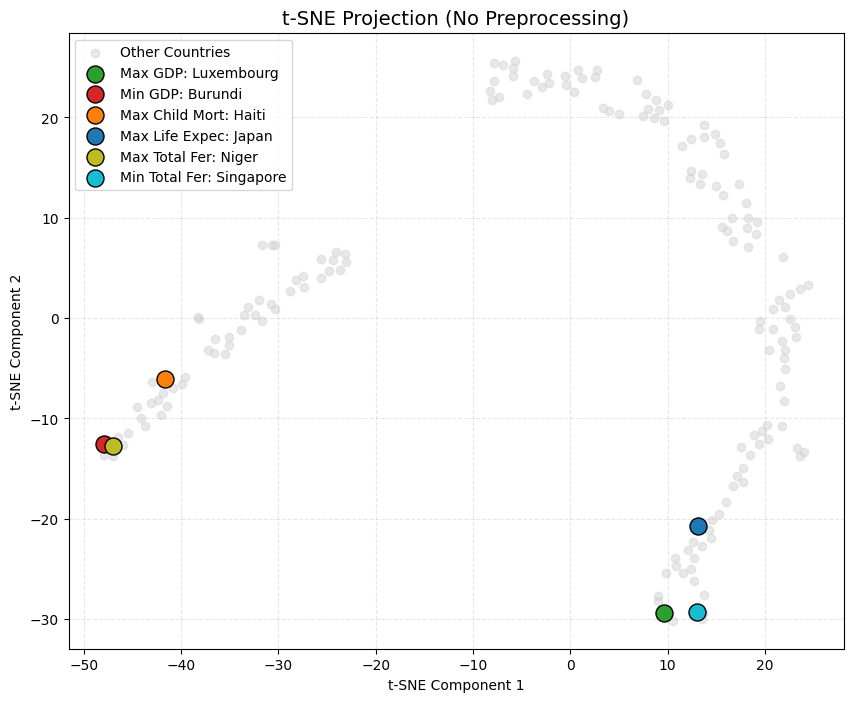

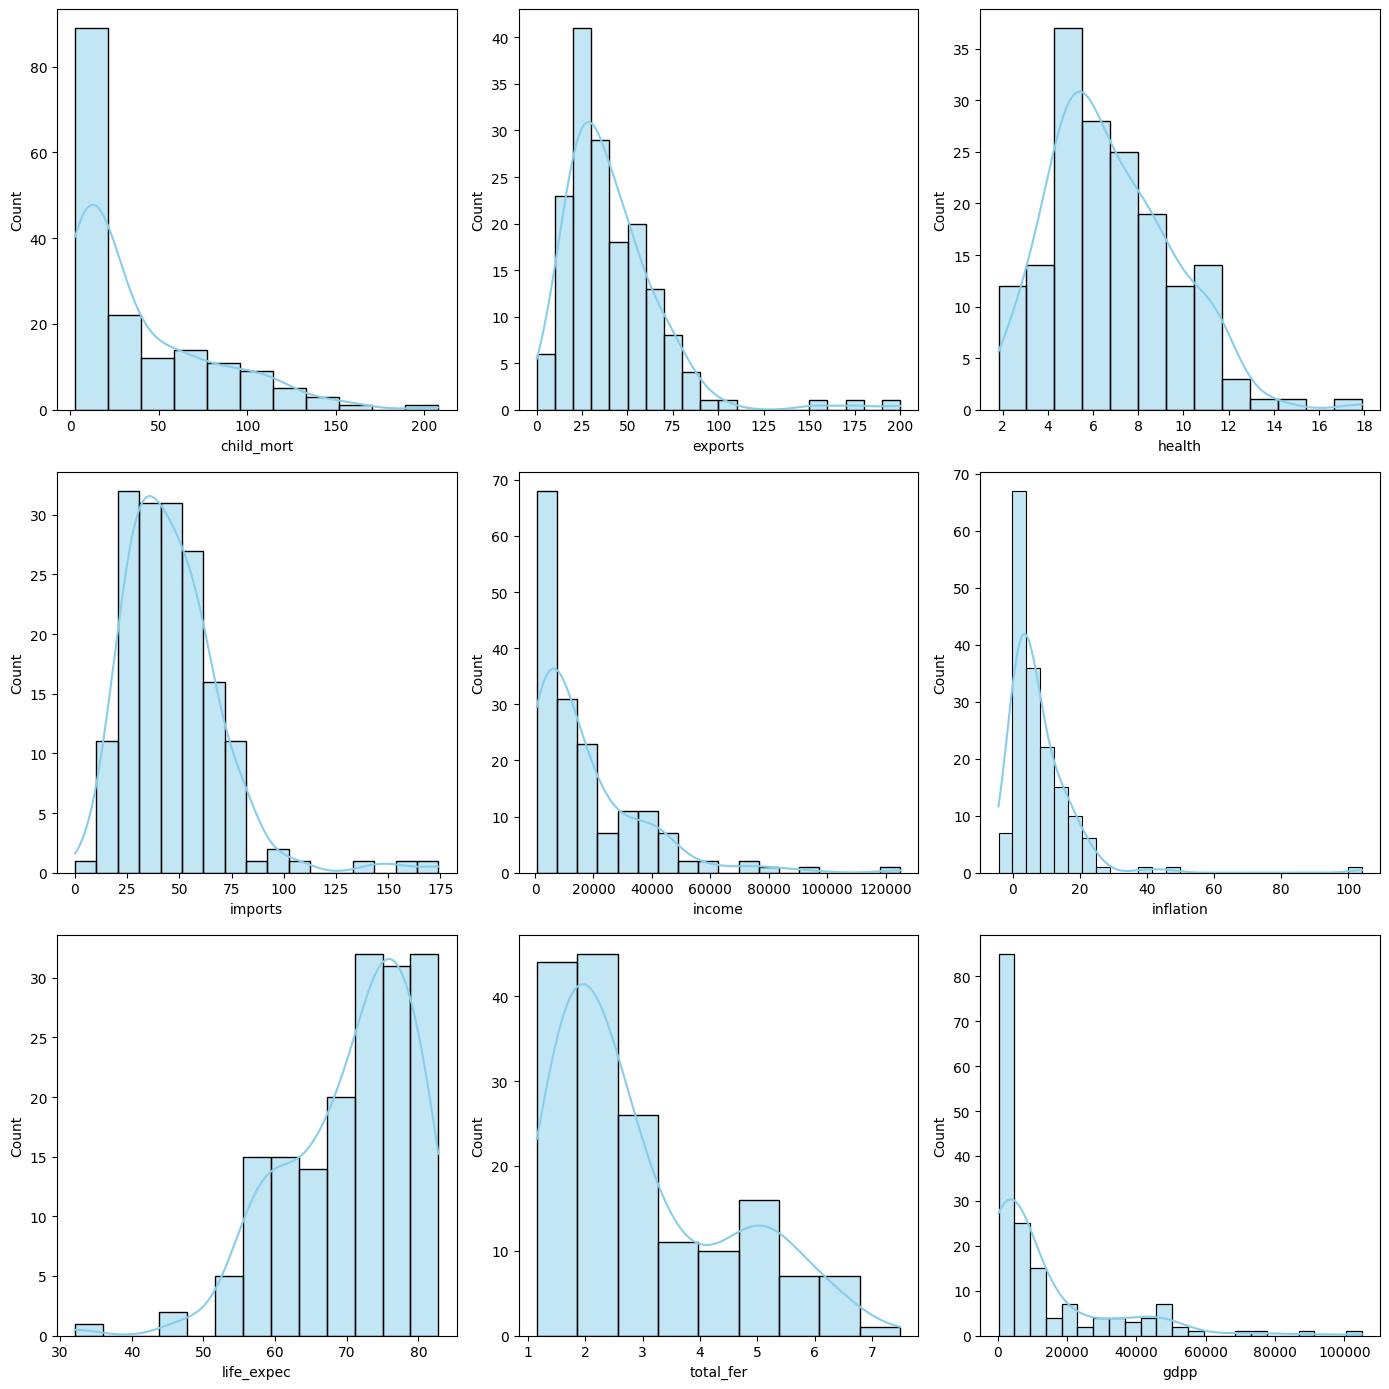

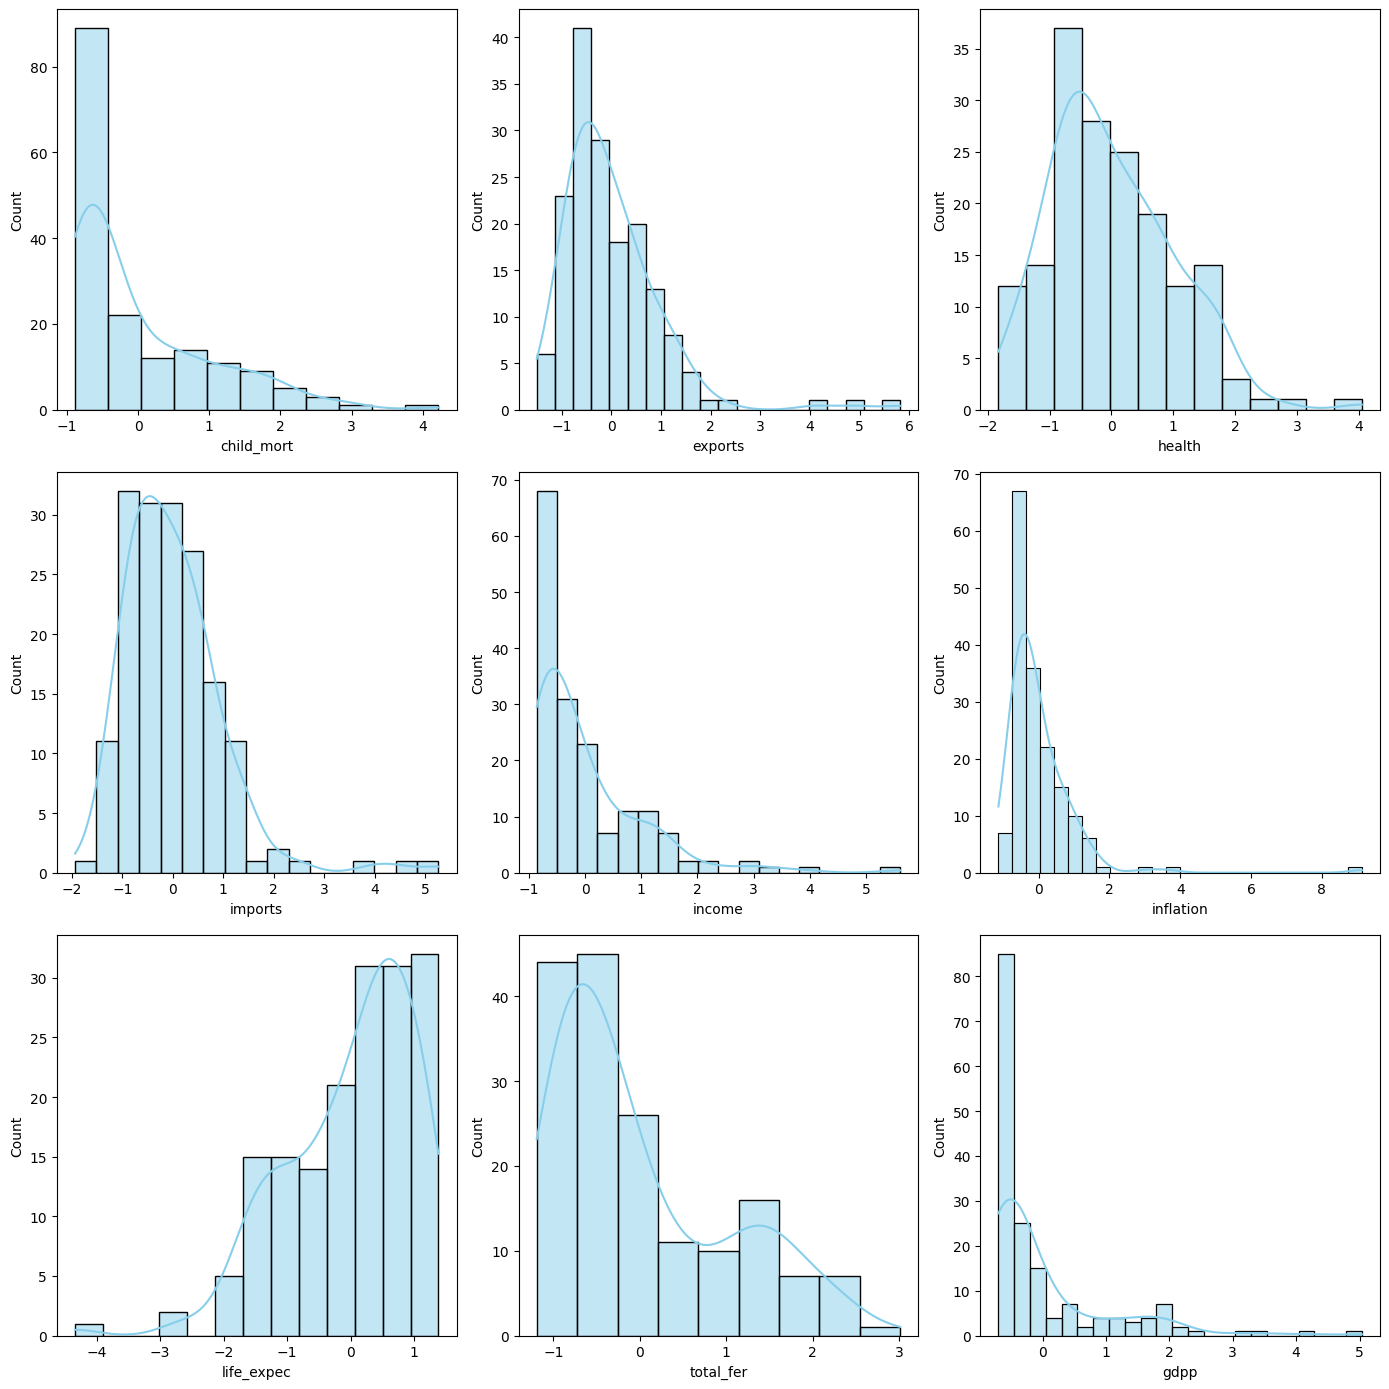

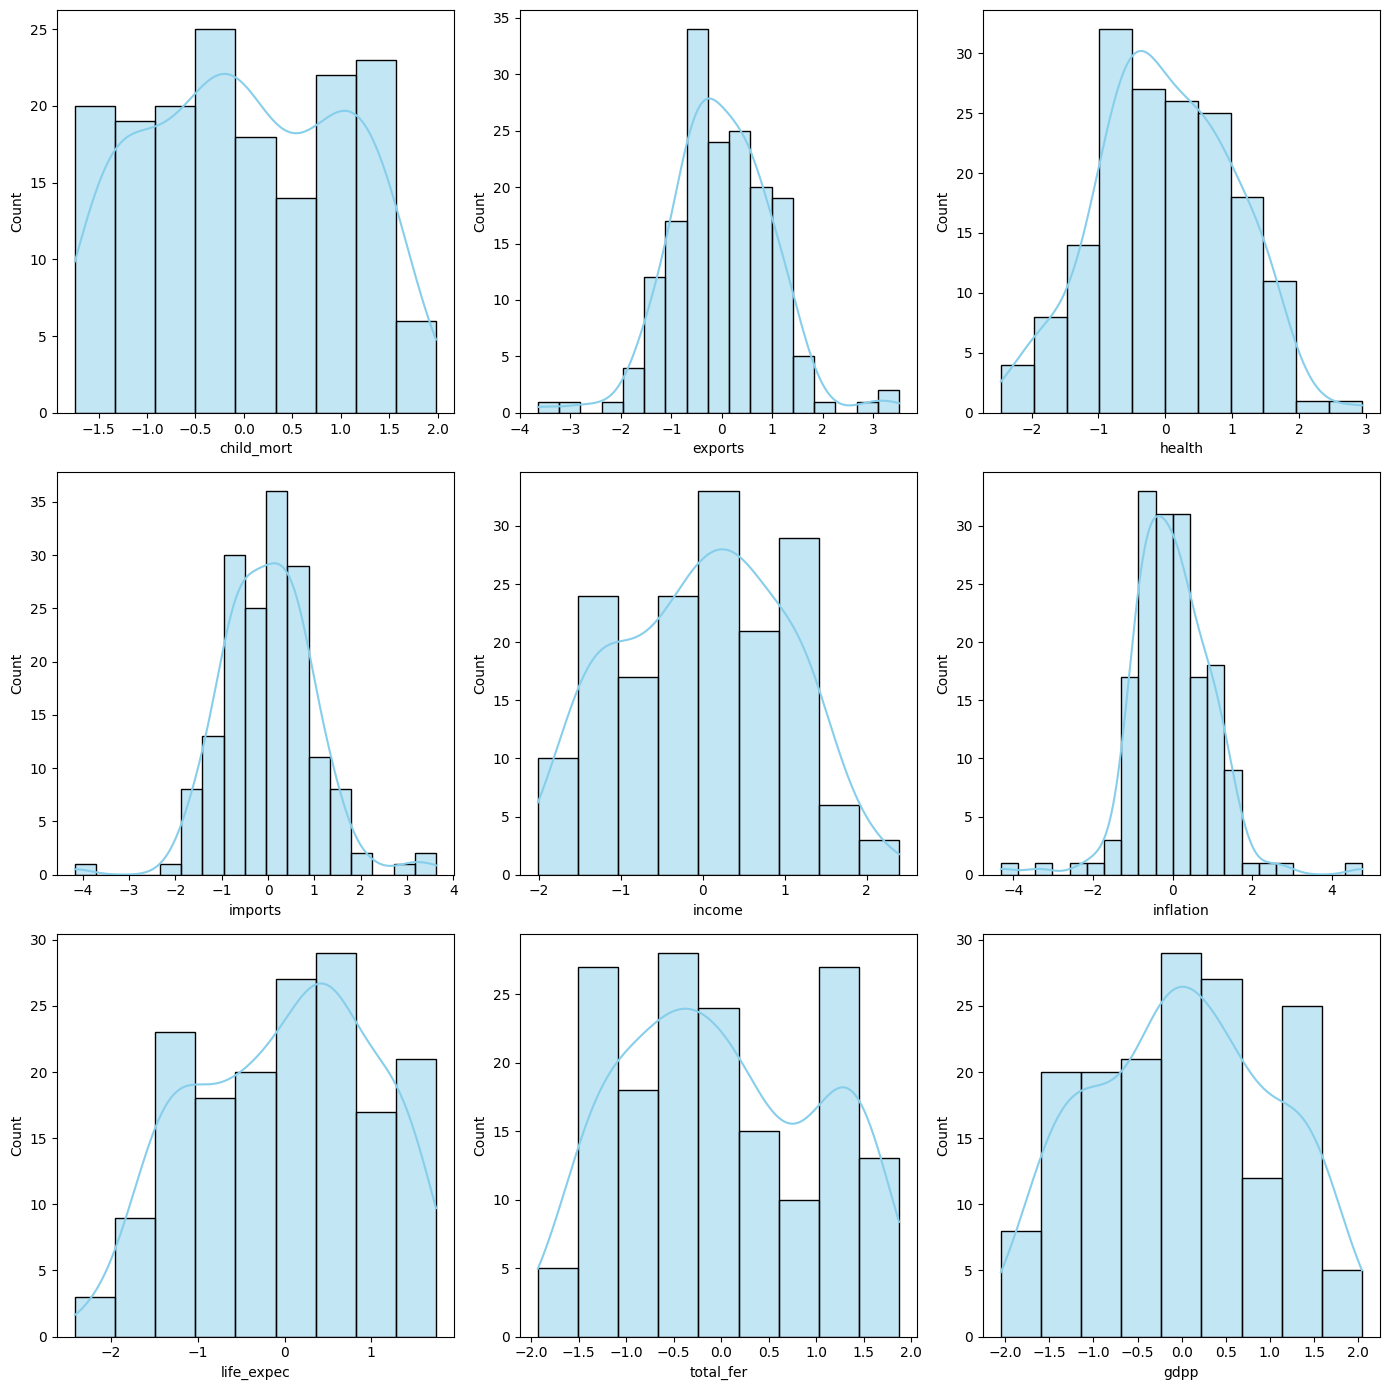

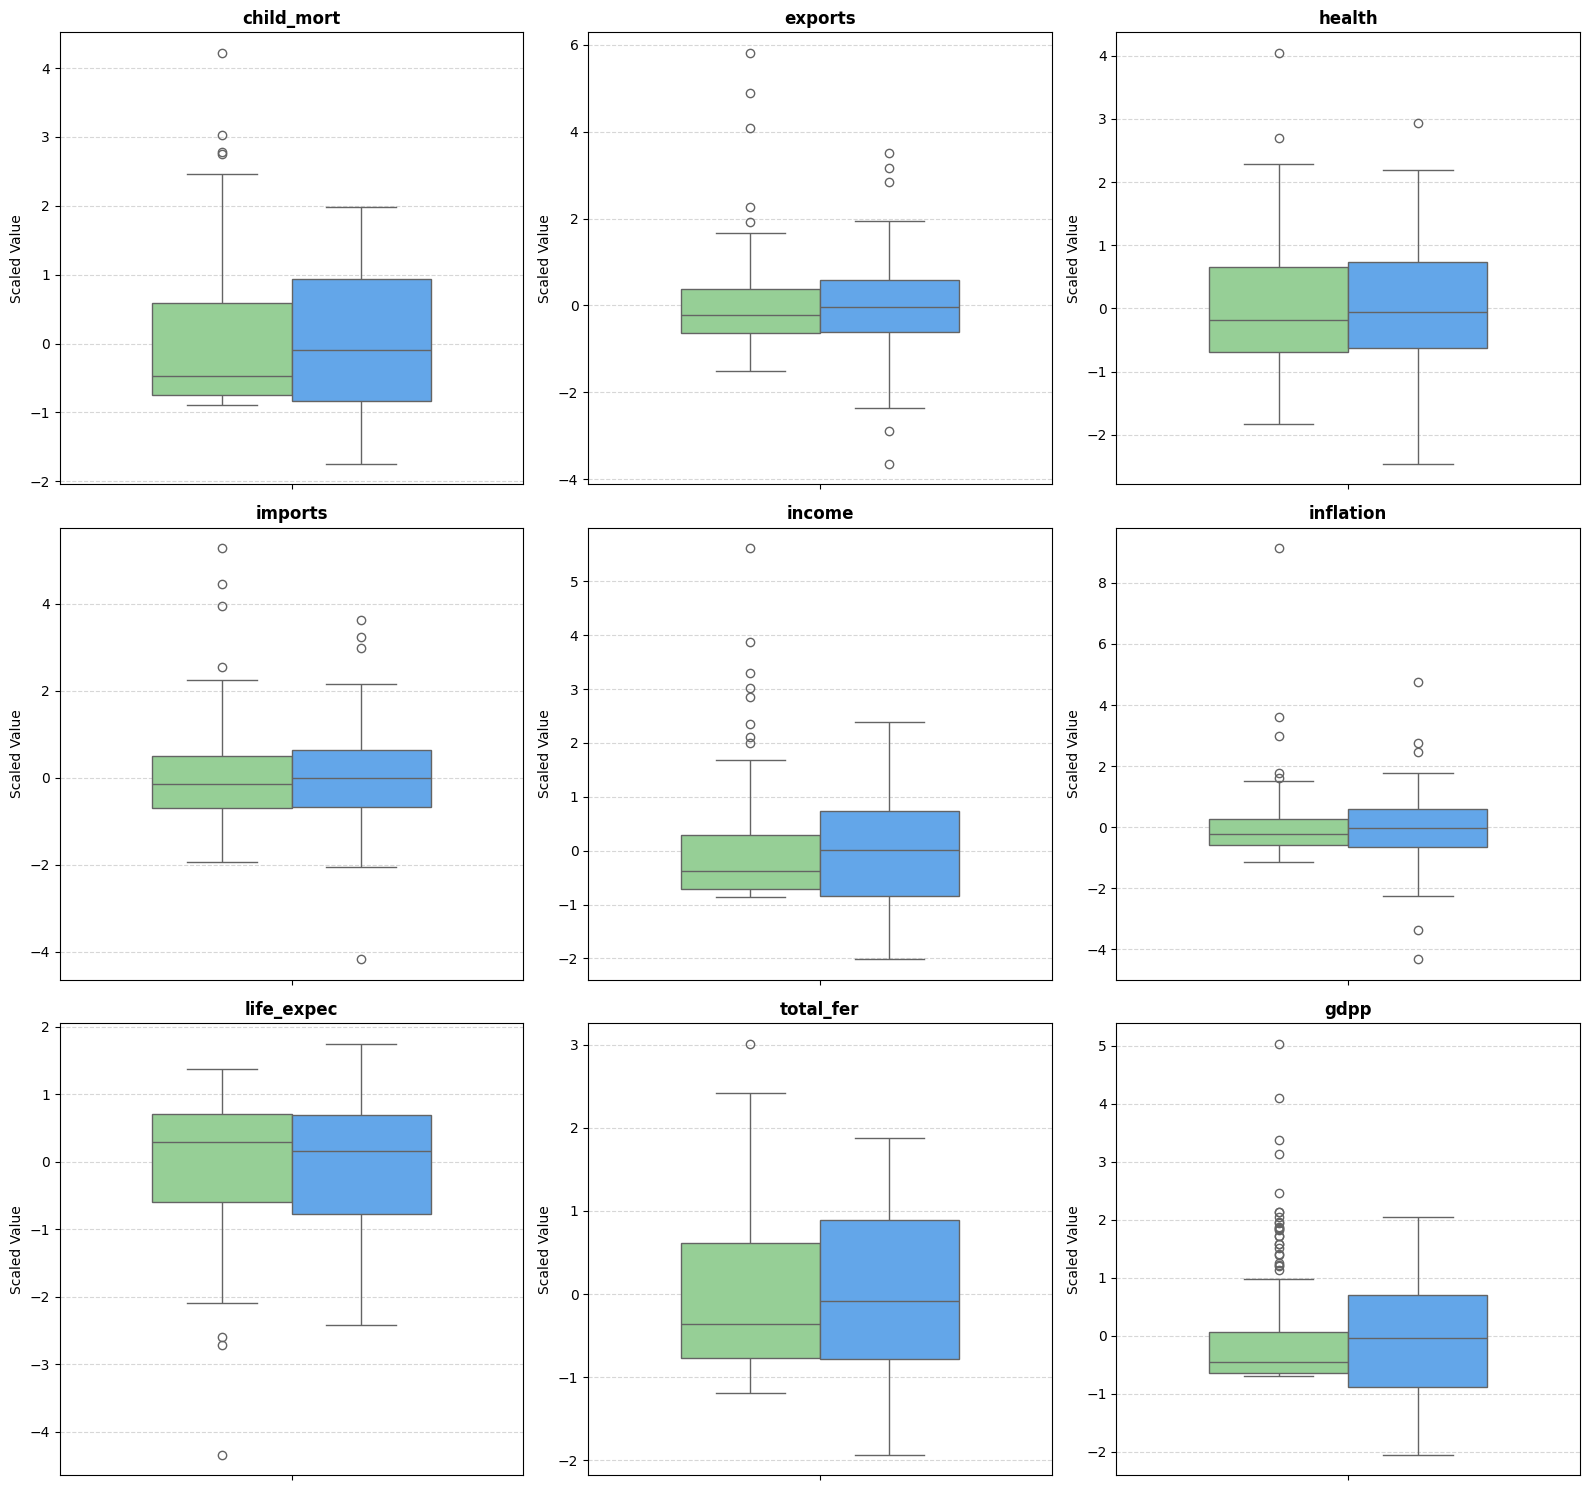

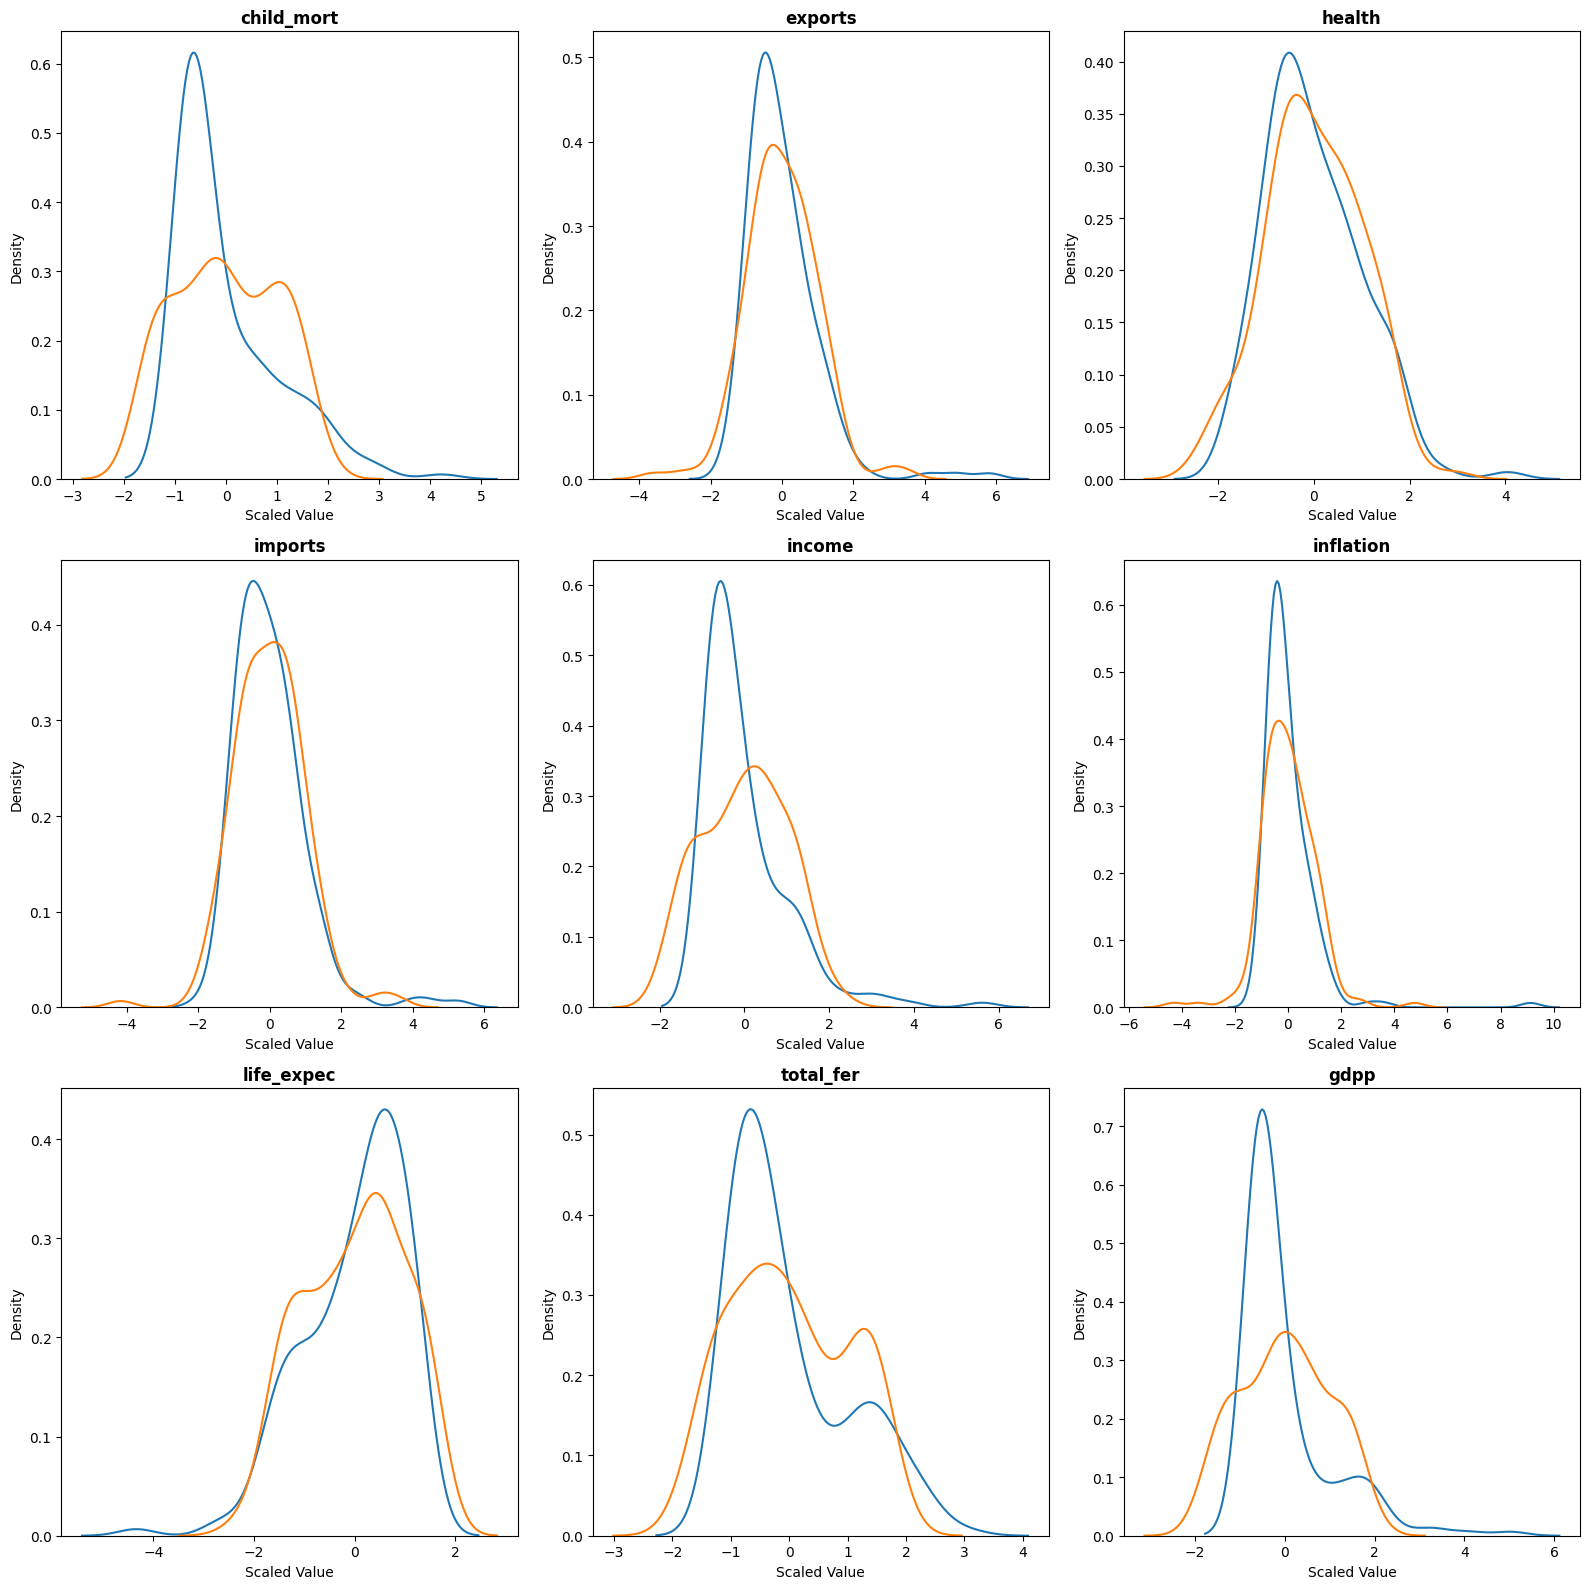

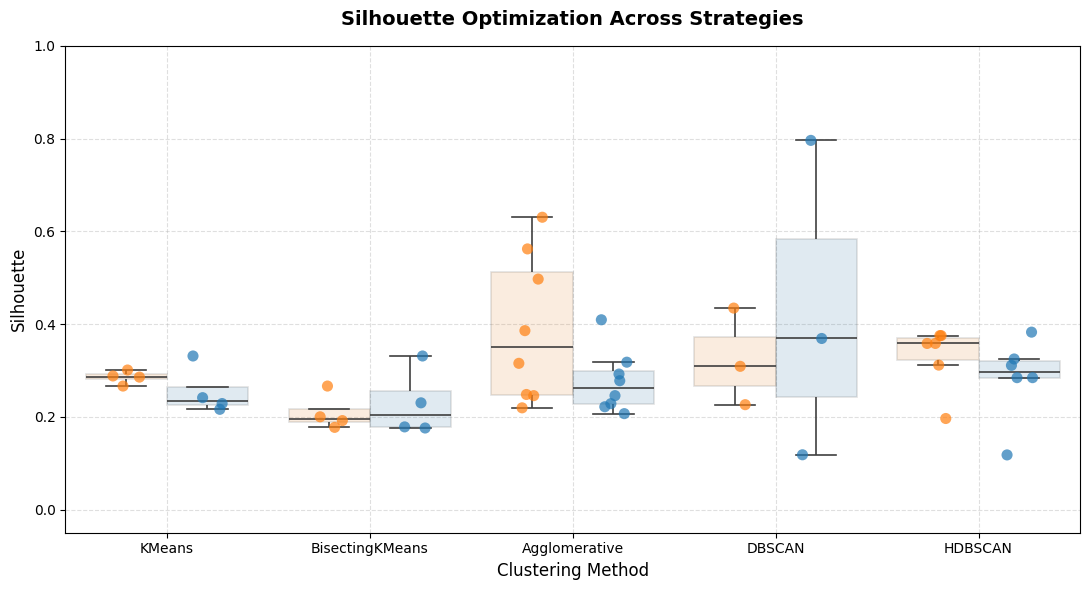

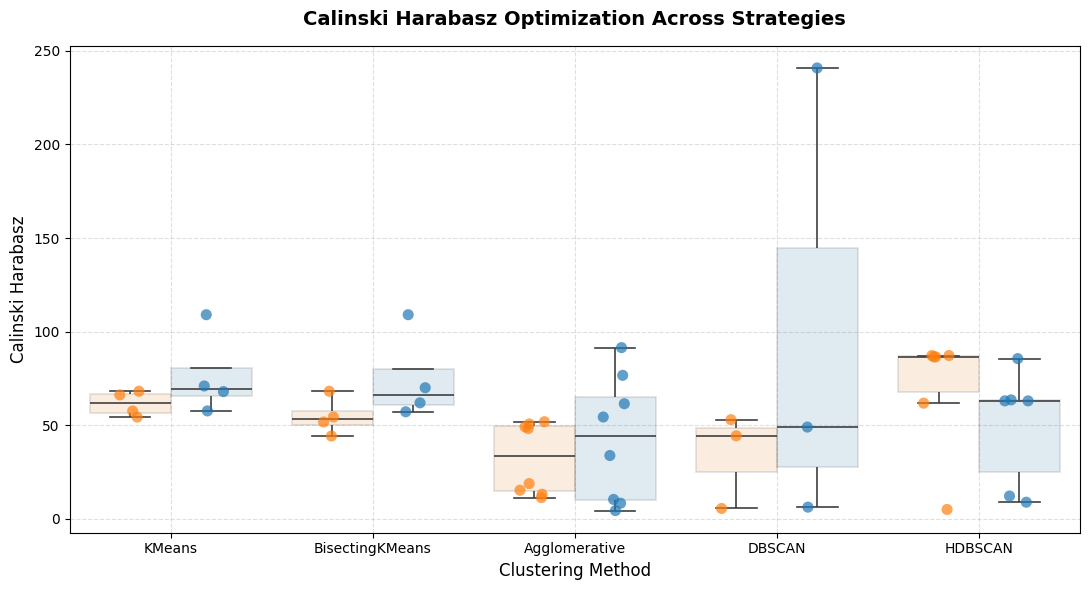

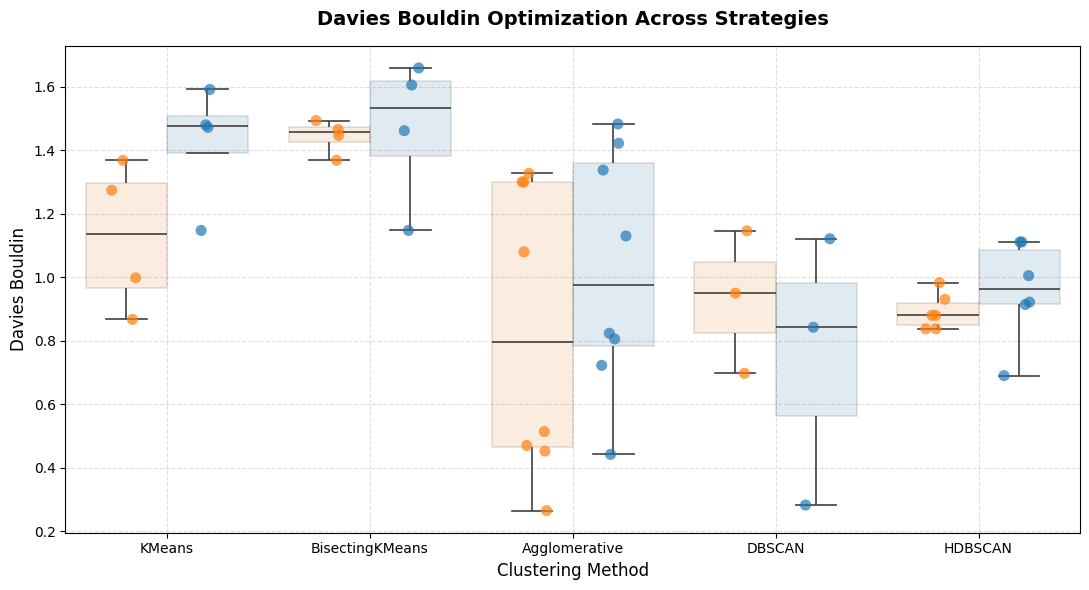

In [72]:
# 1. Ignorant setup
ignorant_analysis(df)

# 2. Extract transformations and graph density/boxplots
all_strategies_data = exploratory_data_analysis(df)

# 3. Analyze clustering optimization for all strategies
optimize_and_plot_clusters(all_strategies_data)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import geopandas as gpd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN

# --- INSERISCI QUI LA TUA SCELTA ---
# Esempio: Scegliamo i dati scalati standard estratti dallo step precedente
# X_chosen = all_strategies_data['Standard Scaling']
# df_original = df  # Il tuo dataframe originale con la colonna 'country'

# Definisci i modelli migliori che vuoi analizzare in base ai tuoi risultati
# Modifica i parametri con quelli che hanno ottenuto gli score migliori!
best_models = {
    'KMeans (Best Silhouette)': KMeans(n_clusters=2, n_init='auto', random_state=42),
    'Agglomerative (Best DB)': AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN (Density)': DBSCAN(eps=1.0, min_samples=5)
}

Calcolo PCA e t-SNE in corso...

ANALISI MODELLO: KMeans (Best Silhouette)

Numero di osservazioni per gruppo:
 - Cluster 0 : 81 paesi
 - Cluster 1 : 86 paesi

Centroidi (Profilo medio delle feature per gruppo):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,0.865652,-0.380373,-0.334839,-0.119289,-0.790309,0.424039,-0.827758,0.814598,-0.793016
1,-0.815323,0.358259,0.315371,0.112354,0.744361,-0.399385,0.779633,-0.767238,0.746910


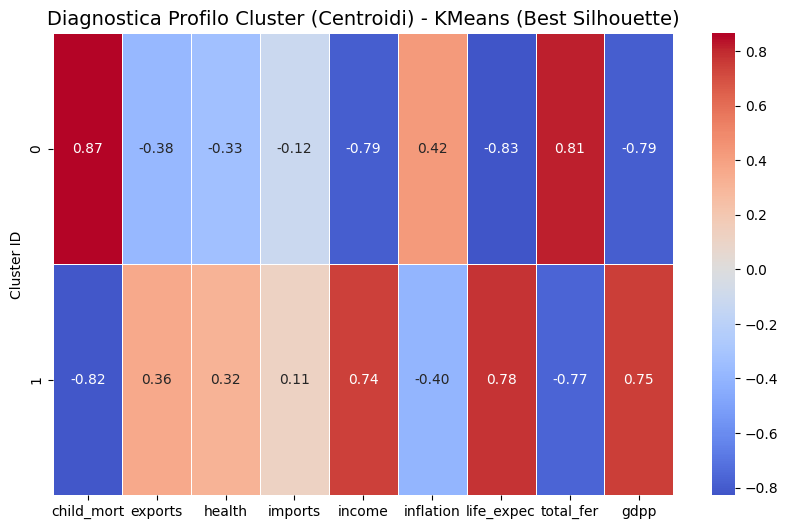

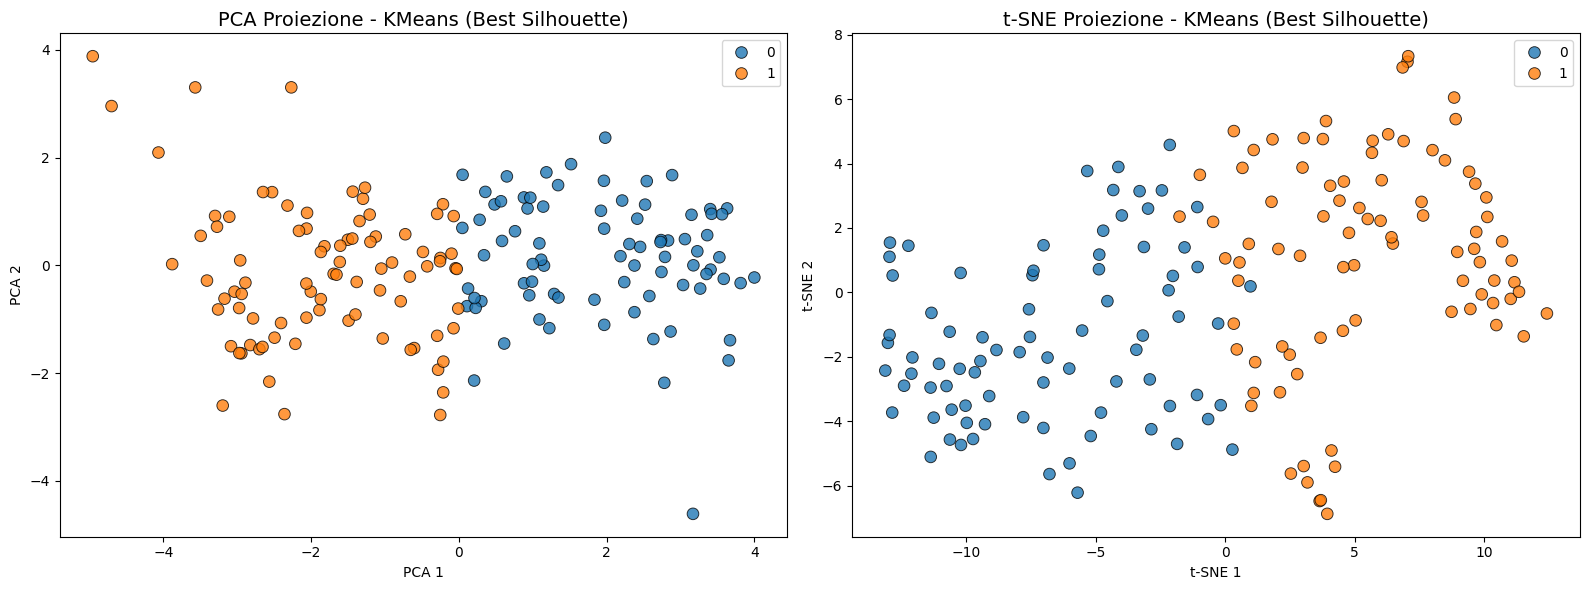

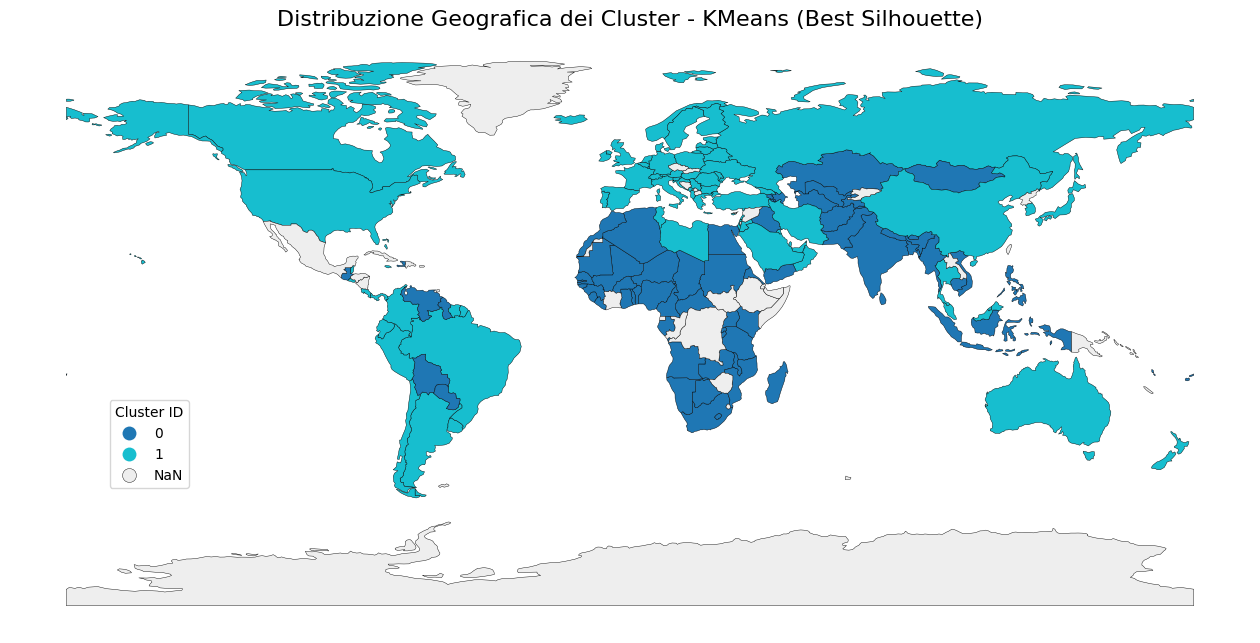


ANALISI MODELLO: Agglomerative (Best DB)

Numero di osservazioni per gruppo:
 - Cluster 0 : 60 paesi
 - Cluster 1 : 53 paesi
 - Cluster 2 : 49 paesi
 - Cluster 3 : 5 paesi

Centroidi (Profilo medio delle feature per gruppo):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,-0.024142,0.186247,-0.434428,-0.073803,0.194317,0.277235,0.091023,-0.068975,0.115618
1,1.150644,-0.653789,-0.282020,-0.221925,-1.094778,0.490471,-1.078072,1.107854,-1.093422
2,-1.090481,0.209358,0.844475,0.053953,0.806756,-0.678149,0.932678,-1.007168,0.906838
3,-1.220411,2.643487,-0.073309,2.709301,1.366635,-1.879951,1.195045,-1.045298,1.315840


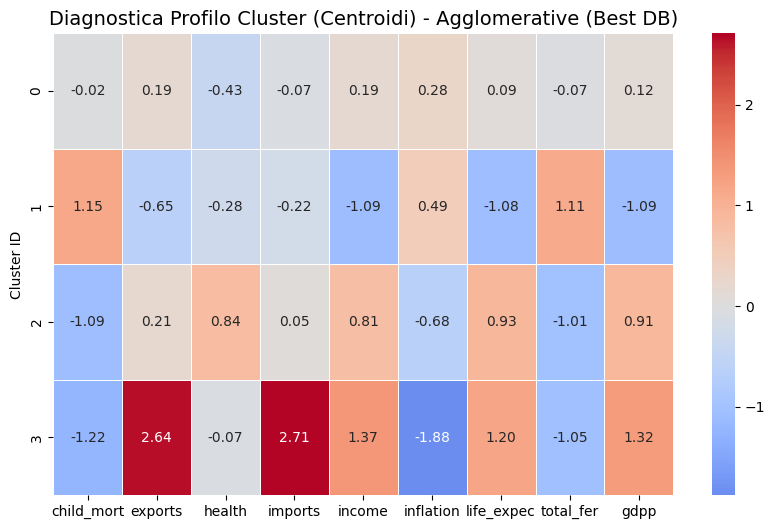

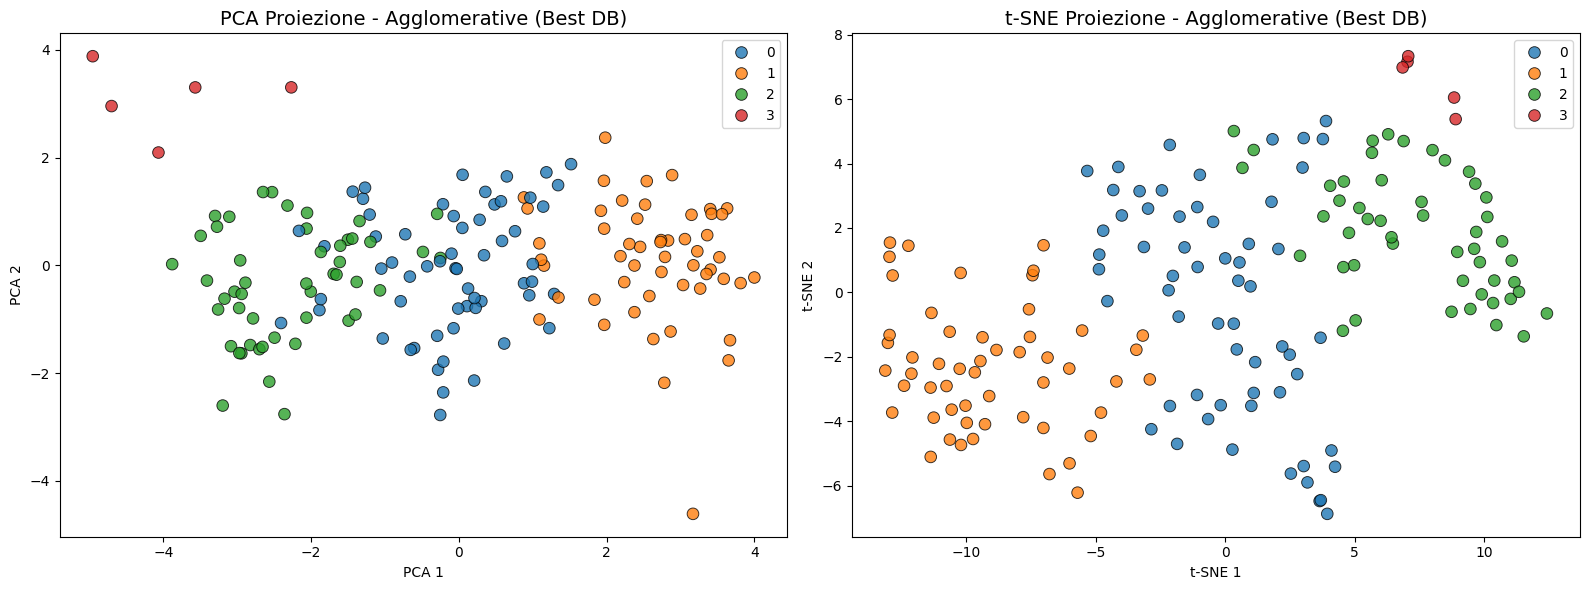

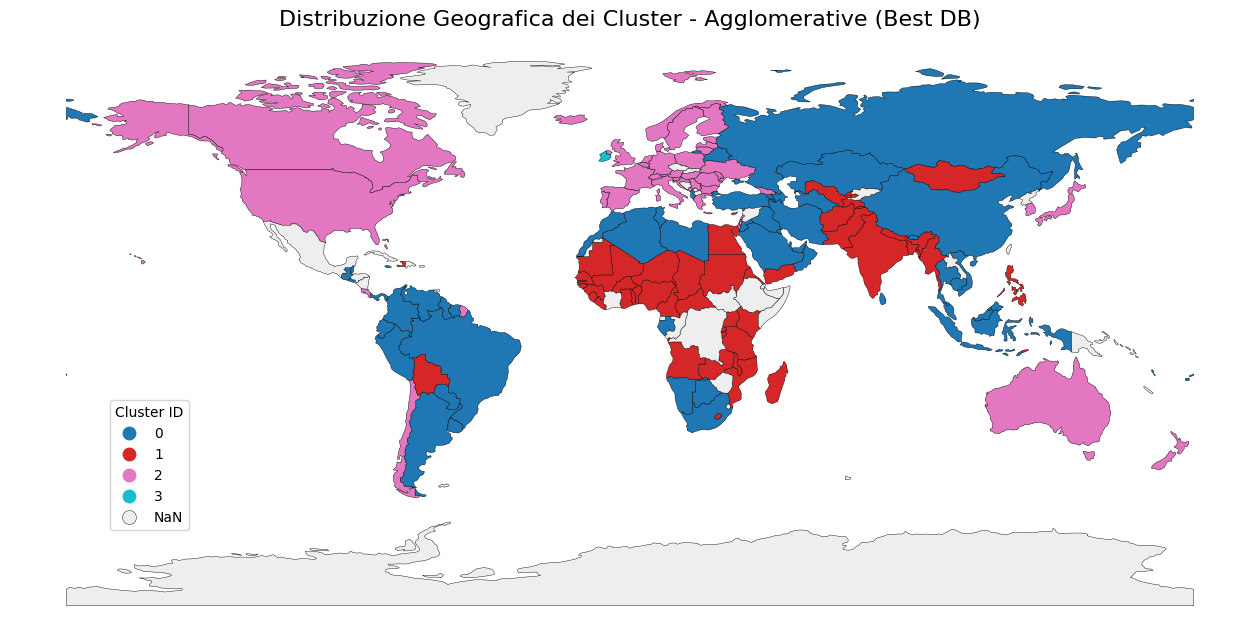


ANALISI MODELLO: DBSCAN (Density)

Numero di osservazioni per gruppo:
 - Cluster -1 (Noise): 144 paesi
 - Cluster 0 : 12 paesi
 - Cluster 1 : 11 paesi

Centroidi (Profilo medio delle feature per gruppo):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,1.315023,-0.725358,-0.231483,-0.442378,-1.295501,-0.120515,-1.289487,1.459063,-1.281703
1,-1.352960,-0.356836,1.205889,-0.676463,1.134009,-0.812908,1.391843,-0.967640,1.345420


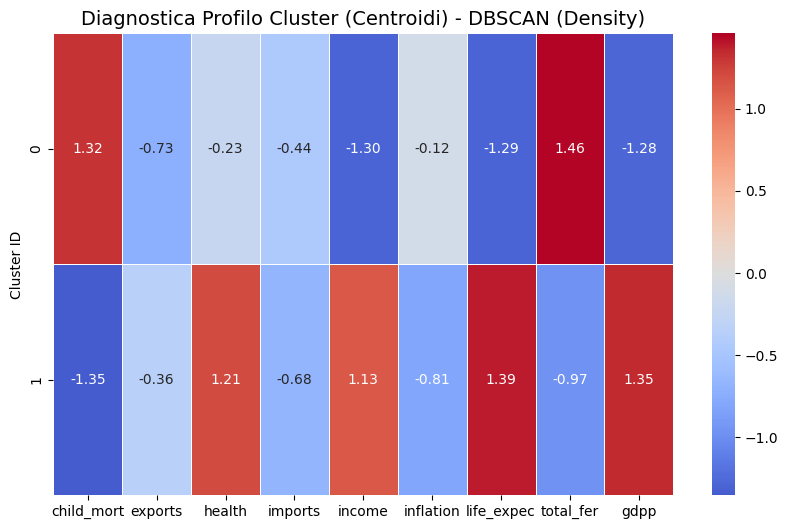

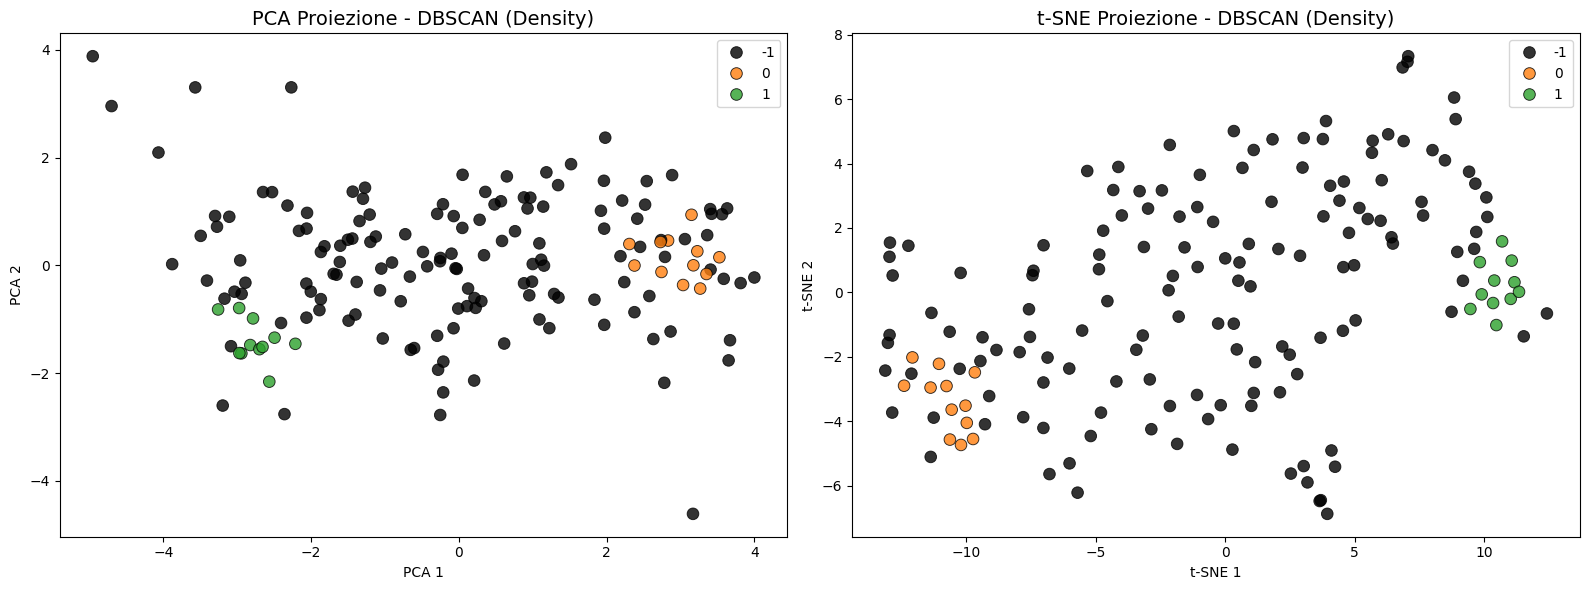

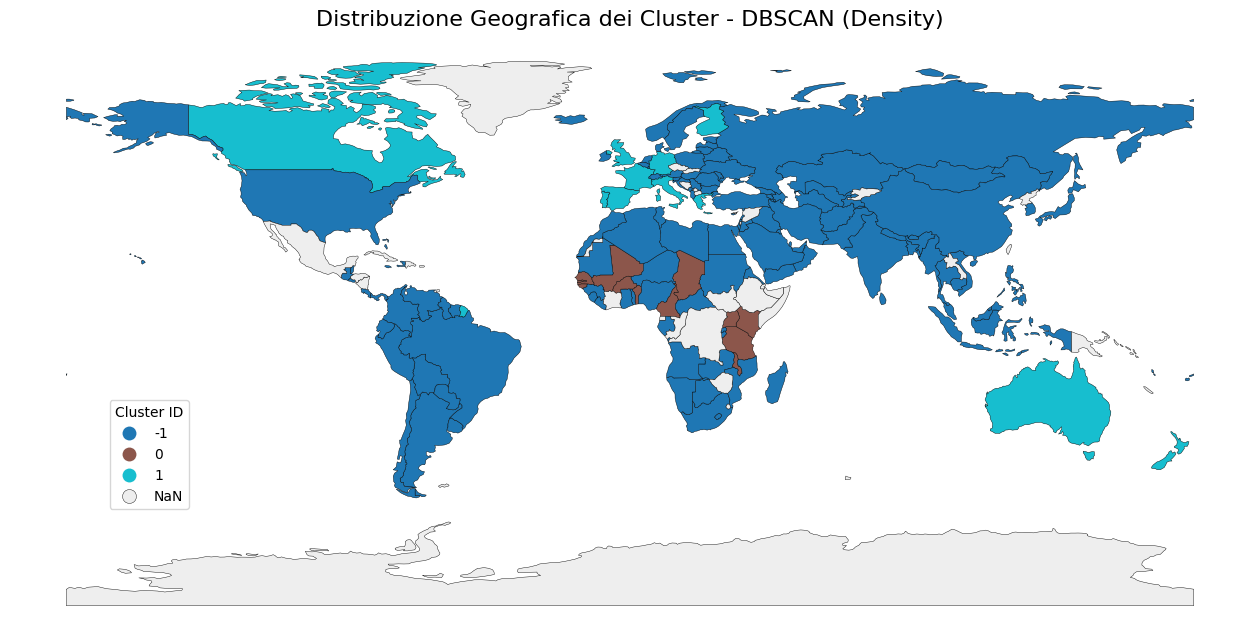

In [15]:
def analyze_best_clusters(df_original, X_chosen, models_dict):
    """
    Esegue l'analisi completa per ogni modello ottimale scelto:
    - Osservazioni e Centroidi
    - Heatmap diagnostica del profilo
    - Proiezioni PCA e t-SNE
    - Mappa Geografica
    """
    country_col = 'country'
    
    # ---------------------------------------------------------
    # FIX: Se X_chosen è un array NumPy, convertilo in DataFrame Pandas
    # ---------------------------------------------------------
    features_names = df_original.drop(columns=[country_col]).columns
    if isinstance(X_chosen, np.ndarray):
        X_chosen_df = pd.DataFrame(X_chosen, columns=features_names)
    else:
        X_chosen_df = X_chosen.copy()
    
    # ---------------------------------------------------------
    # Calcolo preliminare delle proiezioni
    # ---------------------------------------------------------
    print("Calcolo PCA e t-SNE in corso...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_chosen_df)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_chosen_df)
    
    # ---------------------------------------------------------
    # Caricamento della mappa geografica
    # ---------------------------------------------------------
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(world_url)
    except Exception:
        fallback_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
        world = gpd.read_file(fallback_url)
        
    name_column = 'NAME' if 'NAME' in world.columns else 'name'
    
    # ---------------------------------------------------------
    # Ciclo di analisi per ogni modello
    # ---------------------------------------------------------
    for model_name, model in models_dict.items():
        print(f"\n{'='*60}")
        print(f"ANALISI MODELLO: {model_name}")
        print(f"{'='*60}")
        
        # Fit e Predict usando la versione DataFrame/Array coerente
        labels = model.fit_predict(X_chosen_df)
        
        # Ora questa operazione è sicura al 100% su un DataFrame Pandas
        df_results = X_chosen_df.copy()
        df_results['Cluster'] = labels
        
        # --- TASK 1: Numero di osservazioni e Centroidi ---
        print("\nNumero di osservazioni per gruppo:")
        counts = df_results['Cluster'].value_counts().sort_index()
        for cluster_id, count in counts.items():
            tipo = "(Noise)" if cluster_id == -1 else ""
            print(f" - Cluster {cluster_id} {tipo}: {count} paesi")
            
        print("\nCentroidi (Profilo medio delle feature per gruppo):")
        centroids = df_results[df_results['Cluster'] != -1].groupby('Cluster').mean()
        display(centroids)
        
        # Plot Diagnostico: Heatmap dei Centroidi
        plt.figure(figsize=(10, 6))
        sns.heatmap(centroids, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=.5)
        plt.title(f"Diagnostica Profilo Cluster (Centroidi) - {model_name}", fontsize=14)
        plt.ylabel("Cluster ID")
        plt.show()
        
        # --- TASK 2 e 3: Proiezioni PCA e t-SNE ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        unique_labels = np.unique(labels)
        palette = sns.color_palette("tab10", len(unique_labels))
        if -1 in unique_labels:
            color_dict = {label: palette[i] if label != -1 else 'black' for i, label in enumerate(unique_labels)}
        else:
            color_dict = {label: palette[i] for i, label in enumerate(unique_labels)}

        # Plot PCA
        sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette=color_dict, 
                        ax=axes[0], legend='full', s=70, edgecolor='black', alpha=0.8)
        axes[0].set_title(f"PCA Proiezione - {model_name}", fontsize=14)
        axes[0].set_xlabel("PCA 1")
        axes[0].set_ylabel("PCA 2")
        
        # Plot t-SNE
        sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette=color_dict, 
                        ax=axes[1], legend='full', s=70, edgecolor='black', alpha=0.8)
        axes[1].set_title(f"t-SNE Proiezione - {model_name}", fontsize=14)
        axes[1].set_xlabel("t-SNE 1")
        axes[1].set_ylabel("t-SNE 2")
        
        plt.tight_layout()
        plt.show()
        
        # --- TASK 4: Geomap ---
        map_df = df_original[[country_col]].copy()
        map_df['Cluster'] = labels.astype(str)
        
        map_df[country_col] = map_df[country_col].replace({
            "United States": "United States of America",
            "Central African Republic": "Central African Rep.",
            "Democratic Republic of the Congo": "Dem. Rep. Congo"
        })
        
        merged = world.merge(map_df, left_on=name_column, right_on=country_col, how='left')
        
        fig, ax = plt.subplots(1, 1, figsize=(16, 10))
        merged.plot(column='Cluster', ax=ax, categorical=True, legend=True,
                    cmap='tab10', missing_kwds={'color': '#eeeeee'}, 
                    edgecolor='black', linewidth=0.3)
        
        ax.set_title(f"Distribuzione Geografica dei Cluster - {model_name}", fontsize=16)
        ax.axis('off')
        
        leg = ax.get_legend()
        if leg:
            leg.set_bbox_to_anchor((0.15, 0.4))
            leg.set_title("Cluster ID")
            
        plt.show()

# Esegui la pipeline
# Assicurati di passare df (originale) e la matrice X scelta

pt = PowerTransformer(method='yeo-johnson')
X_power_scaled = pt.fit_transform(df.drop(columns='country'))
analyze_best_clusters(df, X_power_scaled, best_models)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import PowerTransformer

# Librerie specifiche per le Reti Bayesiane
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork

# --- 1. Preparazione dei Dati con PowerTransform ---
# Escludiamo la colonna testuale 'country'
X_raw = df.drop(columns=['country'])

pt = PowerTransformer(method='yeo-johnson')
X_power = pt.fit_transform(X_raw)

# Convertiamo in DataFrame mantenendo i nomi originari delle colonne
df_power = pd.DataFrame(X_power, columns=X_raw.columns)

# --- 2. Apprendimento della Struttura (Structure Learning) ---
# Usiamo Hill Climb Search con il punteggio BIC per evitare l'overfitting del grafo
print("Apprendimento della struttura della Rete Bayesiana in corso...")
estimator = HillClimbSearch(df_power)
best_model = estimator.estimate(scoring_method=BicScore(df_power), max_indegree=3)

# Creiamo la rete bayesiana effettiva partendo dagli archi trovati
bayesian_net = BayesianNetwork(best_model.edges())

print(f"Rete creata con successo! Numero di archi (relazioni): {len(bayesian_net.edges())}")
print("Archi trovati:", bayesian_net.edges())

# --- 3. Plot della Rete Bayesiana ---
plt.figure(figsize=(12, 10))

# Convertiamo il modello pgmpy in un grafo NetworkX per personalizzare il plot
nx_graph = nx.DiGraph(bayesian_net.edges())

# Aggiungiamo eventuali nodi isolati che non hanno archi (se presenti)
nx_graph.add_nodes_from(df_power.columns)

# Scegliamo un layout circolare o a molla (spring) per distribuire bene i nodi
pos = nx.spring_layout(nx_graph, seed=42, k=1.5)

# Disegniamo i nodi con un design pulito ed estetico
nx.draw_networkx_nodes(
    nx_graph, pos, 
    node_color='lightblue', 
    node_size=3000, 
    edgecolors='black', 
    linewidths=1.5
)

# Disegniamo gli archi (frecce orientate che indicano la dipendenza condizionale)
nx.draw_networkx_edges(
    nx_graph, pos, 
    edge_color='gray', 
    arrowsize=25, 
    arrowstyle='->', 
    width=2.0,
    connectionstyle='arc3,rad=0.1' # Curva leggermente gli archi per evitare sovrapposizioni
)

# Aggiungiamo i nomi delle colonne come etichette dei nodi
nx.draw_networkx_labels(
    nx_graph, pos, 
    font_size=11, 
    font_weight='bold', 
    font_family='sans-serif'
)

plt.title("Struttura della Rete Bayesiana Appresa (Dati Power Transformed)", fontsize=16, fontweight='bold', pad=20)
plt.axis('off') # Nascondiamo gli assi cartesiani

# Salviamo l'immagine risultante
plt.savefig('4_bayesian_network.png', bbox_inches='tight', dpi=300)
plt.show()

/home/lollinux/lorenzoliuzzo/unsupervised-learning-on-country-data/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'BicScore' from 'pgmpy.estimators' (/home/lollinux/lorenzoliuzzo/unsupervised-learning-on-country-data/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py)

In [66]:
import scipy.stats as stats
import pandas as pd

def evaluate_strategies_statistically(all_results_df):
    """
    Performs a Wilcoxon Signed-Rank test across matching configurations
    to determine if one preprocessing strategy significantly outperforms the other.
    """
    metrics = ['Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin']
    
    print("="*60)
    print("  WILCOXON SIGNED-RANK TEST: STANDARD SCALING vs POWER TRANSFORM  ")
    print("="*60)
    
    for metric in metrics:
        # 1. Pivot the data so Standard Scaling and Power Transform sit side-by-side for each config
        paired_data = all_results_df.pivot(
            index='Configuration', 
            columns='Strategy', 
            values=metric
        ).dropna() # Only compare configurations that succeeded in both strategies
        
        if len(paired_data) < 5:
            print(f"\nMetric: {metric}")
            print(f"-> Skip: Too few overlapping successful configurations ({len(paired_data)}) to test.")
            continue
            
        group_std = paired_data['Standard Scaling']
        group_power = paired_data['Power Transform']
        
        # 2. Run the non-parametric paired test
        stat, p_value = stats.wilcoxon(group_std, group_power)
        
        # 3. Interpret the results
        print(f"\nMetric: {metric} (n = {len(paired_data)} matched pairs)")
        print(f"-> Statistic: {stat:.4f} | p-value: {p_value:.5f}")
        
        alpha = 0.05
        if p_value < alpha:
            # Determine which one is actually better
            # Note: For Davies_Bouldin, lower score is better!
            mean_std = group_std.mean()
            mean_power = group_power.mean()
            
            if metric == 'Davies_Bouldin':
                winner = "Power Transform" if mean_power < mean_std else "Standard Scaling"
            else:
                winner = "Power Transform" if mean_power > mean_std else "Standard Scaling"
                
            print(f"-> Result: Significant difference detected! Win goes to: **{winner}**")
        else:
            print("-> Result: No statistically significant difference between the strategies.")
            
    print("="*60)

In [67]:
# Inside your main script pipeline:
evaluate_strategies_statistically(all_results_df)

NameError: name 'all_results_df' is not defined